In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
# Mathematical operations

t = torch.tensor([1, 2, 3], dtype=torch.float32)
print(t[0].item()) # to access the value of a 0-dim tensor as a standard Python number. It is used to extract the single value from a tensor that contains only one element, allowing you to work with it as a regular Python scalar.
print(t.exp())
print(t.log())
print(t.sum().item())
print(t.mean(0).item())

1.0
tensor([ 2.7183,  7.3891, 20.0855])
tensor([0.0000, 0.6931, 1.0986])
6.0
2.0


In [3]:
# Randomness and reproducibility

torch.manual_seed(42) # pytorch use this seed automatically; and it automatically change(increment) it's(RNG random number generator) state after each call to a random functions, BUT if you want to reproduce the same results, you can set it again to the same value before calling another random functions

g = torch.Generator().manual_seed(42) # similar to the above but instead it is passed explicitly as a parameter to the random functions

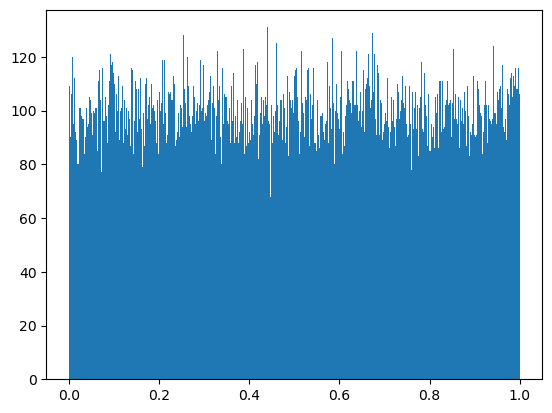

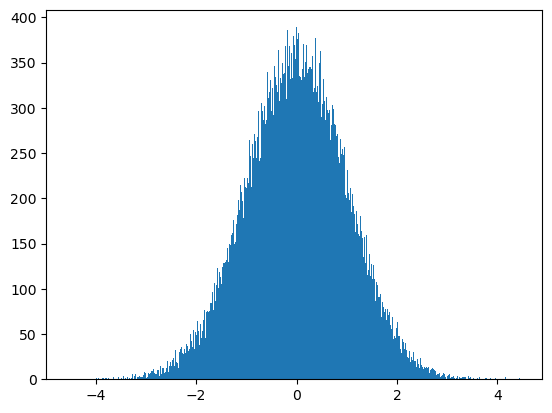

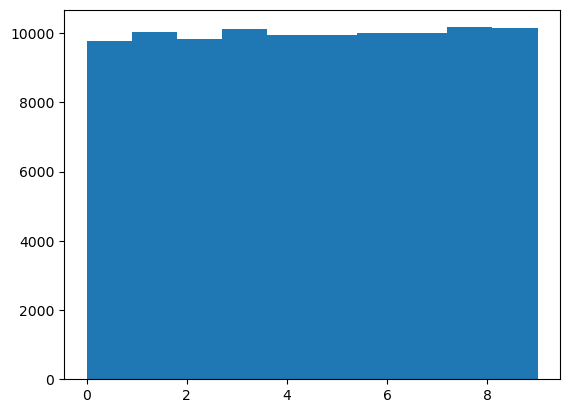

In [4]:
# Random tensors in torch

torch.manual_seed(42)

# torch.rand(size)
# -> Uniform distribution in [0, 1)
# -> Returns FLOAT tensor
torch.rand(3)      # e.g. tensor([0.88, 0.91, 0.38])
plt.hist(torch.rand(100_000), bins=1000)
plt.show()

# torch.randn(size)
# -> Normal/Gaussian distribution (mean=0, std=1)
# -> Returns FLOAT tensor
torch.randn(3)     # e.g. tensor([ 0.34, -1.12,  0.23])
plt.hist(torch.randn(100_000), bins=1000)
plt.show()

# torch.randint(low, high, size)
# -> Uniform random INTEGERS in [low, high)
# -> Returns INT tensor
torch.randint(0, 10, (3,))  # e.g. tensor([2, 7, 6])
plt.hist(torch.randint(0, 10, (100_000,)), bins=10)
plt.show()

In [5]:
# Tensor dimensions and the broadcasting in torch

t = torch.rand((27, 27))

print(t.sum().shape) # add up all the elements from all the dimensions and return a single scalar value, resulting in a tensor of shape ().

print(t.sum(1).shape) # add up the elements across the columns for each row, resulting in a 1D tensor of shape (27,)
print(t.sum(1, keepdims=True).shape) # add up the elements across the columns for each row, resulting in a 2D tensor of shape (27, 1) due to keepdims=True, which keeps the original number of dimensions.

print(t.sum(0).shape)
print(t.sum(0, keepdims=True).shape)

# broadcasting in torch
t_sum = t.sum(1, keepdims=True) # (27, 1)
t_res = t / t_sum # (27, 27) / (27, 1) -> broadcasting to (27, 27)
print()
print(t_res.shape) # (27, 27)

torch.Size([])
torch.Size([27])
torch.Size([27, 1])
torch.Size([27])
torch.Size([1, 27])

torch.Size([27, 27])


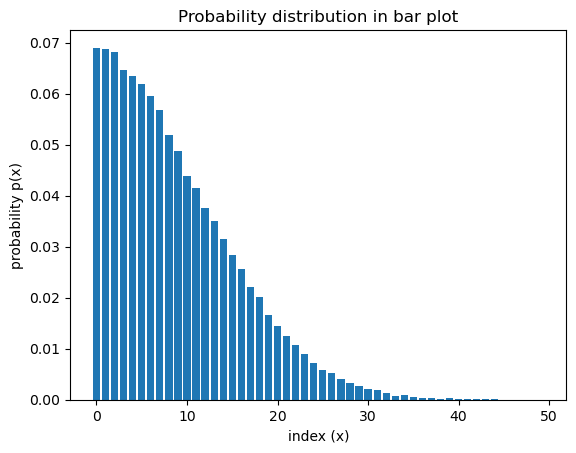

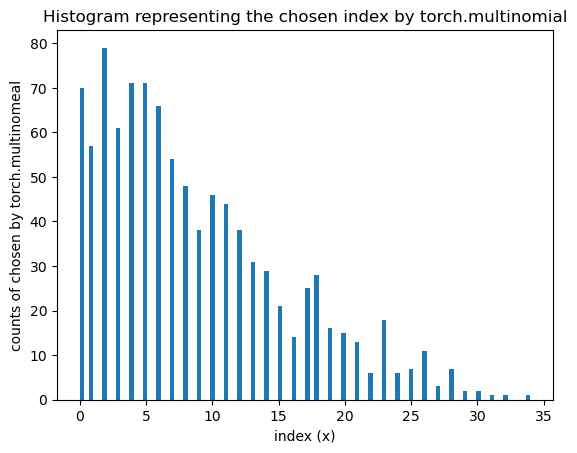

In [6]:
# multinomial sampling

# higher probability means more likely to be chosen, it returns the index of the chosen character

# preparing dummy probabilities
dist = torch.randn((100000,)).abs()
counts, bin_edges = torch.histogram(dist, bins=50) # it returns the data necessary to plot the histogram
p_dist = counts / counts.sum()


plt.bar(torch.arange(50), p_dist)
plt.title("Probability distribution in bar plot")
plt.xlabel("index (x)")
plt.ylabel("probability p(x)")
plt.show()

ix = torch.multinomial(p_dist, num_samples=1000, replacement=True) # sample from the probability distribution, higher probability means more likely to be chosen, it returns the index of the chosen character
plt.hist(ix, bins=100)
plt.title("Histogram representing the chosen index by torch.multinomial")
plt.xlabel("index (x)")
plt.ylabel("counts of chosen by torch.multinomeal")
plt.show()

In [7]:
# Pytorch Indexing

# ── Simple Indexing ──────────────────────────────────────────────────────────
# Uses scalars or slices only. Always returns a VIEW (shared memory, no copy).

t = torch.randn((27, 27))  # shape: (27, 27)

# --- Row / Column selection ---
print(t[0])         # shape: (27,)   — row 0,    drops first dim
print(t[-1])        # shape: (27,)   — last row, drops first dim
print(t[:, 0])      # shape: (27,)   — col 0,    drops second dim
print(t[:, -1])     # shape: (27,)   — last col, drops second dim

# --- Scalar (single element) ---
print(t[0, 0])      # shape: ()      — scalar, both dims dropped
print(t[3, 7])      # shape: ()      — element at row 3, col 7

# --- Slicing (range of rows/cols) ---
print(t[0:5])       # shape: (5, 27)  — rows 0-4, all cols
print(t[:, 0:5])    # shape: (27, 5)  — all rows, cols 0-4
print(t[0:5, 0:5])  # shape: (5, 5)   — top-left 5x5 block
print(t[::2])       # shape: (14, 27) — every other row (step=2)

# --- Keeping dims with slice vs scalar ---
print(t[0].shape)       # (27,)   — dim dropped  (scalar index)
print(t[0:1].shape)     # (1, 27) — dim kept     (slice index)
print(t[:, 0].shape)    # (27,)   — dim dropped
print(t[:, 0:1].shape)  # (27, 1) — dim kept


# ── Advanced (Fancy) Indexing ────────────────────────────────────────────────
# Uses integer tensors of any shape as indices.
# Always returns a COPY (not a view).
#
# Rule:  output.shape = index.shape + tensor.shape[1:]
#        (index replaces the first (0th) dimension of the tensor)

t = torch.randn((27, 27))  # shape: (27, 27)

# --- 1D index on 2D tensor ---
# index.shape=(10,), tensor.shape=(27,27) → output=(10,)+(27,) = (10, 27)
idxs = torch.randint(0, 27, (10,))  # shape: (10,)
print(t[idxs])                       # shape: (10, 27) — 10 selected rows

# --- 2D index on 2D tensor (embedding lookup) ---
# index.shape=(10,3), tensor.shape=(27,2) → output=(10,3)+(2,) = (10, 3, 2)
Xtr = torch.randint(0, 27, (10, 3))  # shape: (10, 3) — 10 contexts, length 3
C   = torch.randn((27, 2))           # shape: (27, 2) — 27 tokens, embed_dim=2
emb = C[Xtr]                         # shape: (10, 3, 2)
#
# what happens step by step:
#   Xtr[0]    = [4, 15, 22]           — context 0: 3 token ids
#   C[4]      = [x, x]                — embedding of token 4,  shape: (2,)
#   C[15]     = [x, x]                — embedding of token 15, shape: (2,)
#   C[22]     = [x, x]                — embedding of token 22, shape: (2,)
#   emb[0]    = [[x,x],[x,x],[x,x]]  — 3 embeddings stacked,  shape: (3, 2)
#   emb       → all 10 contexts       —                        shape: (10, 3, 2)

# --- 3D index on 2D tensor ---
# index.shape=(2,4,3), tensor.shape=(27,2) → output=(2,4,3)+(2,) = (2, 4, 3, 2)
Xbatch = torch.randint(0, 27, (2, 4, 3))  # shape: (2, 4, 3)
emb2   = C[Xbatch]                         # shape: (2, 4, 3, 2)


# ── Boolean (Mask) Indexing ──────────────────────────────────────────────────
# Uses a bool tensor as a mask. Always returns a COPY.
# Flattens the masked dimension → output is always 1D along that axis.

t = torch.randn((5, 4))   # shape: (5, 4)

# --- Mask on entire tensor (element-wise) ---
mask = t > 0              # shape: (5, 4), dtype: bool
print(t[mask])            # shape: (N,)   — N = number of True values, unpredictable

# --- Mask on rows (1D mask over first dim) ---
row_mask = torch.tensor([True, False, True, False, True])  # shape: (5,)
print(t[row_mask])        # shape: (3, 4) — only rows where mask is True

# --- Practical use: ignore padding tokens in loss ---
# targets shape : (B, T) = (8, 16)
# loss    shape : (B, T) = (8, 16)
B, T     = 8, 16
pad_id   = 0
targets  = torch.randint(0, 27, (B, T))   # shape: (8, 16)
loss_all = torch.randn((B, T))            # shape: (8, 16)  — per-token loss
mask     = targets != pad_id              # shape: (8, 16), dtype: bool
loss     = loss_all[mask].mean()          # shape: ()  — scalar, pads excluded

tensor([ 0.1250, -1.9120, -0.7859, -1.0091, -0.6299, -0.1530,  0.3834,  0.2136,
        -2.7156, -0.0591, -0.1335,  0.4064,  0.2972, -1.8647,  0.6988, -0.1457,
        -0.5175,  0.2233,  0.7300, -1.3571, -0.4970,  0.7683, -0.6427,  2.5611,
        -0.0903, -1.4016, -1.3845])
tensor([-0.3999, -1.8246,  0.9764,  1.5186, -2.9027, -0.6591, -0.1401,  1.3810,
        -0.4706,  0.1199,  1.2973, -0.9899,  1.4003, -0.3716, -0.4640, -0.6425,
        -1.5237,  1.5665, -0.6277, -0.9294, -0.5512, -0.3672,  0.0485,  0.5306,
        -0.0297,  1.9841,  0.0336])
tensor([ 0.1250, -0.7113,  0.6312,  0.1425,  2.0577,  0.3453, -1.0674, -0.2816,
        -0.0444,  0.7429,  0.3413, -0.9596,  0.2669,  0.6227, -0.7536,  0.0559,
        -0.2367,  0.0585, -1.6234,  0.7101, -0.4697,  0.3553,  0.4628,  1.7634,
        -0.5567,  0.6410, -0.3999])
tensor([-1.3845, -0.8859,  0.3685, -2.4375, -0.6033, -0.1879, -0.0921,  0.2746,
        -0.6223,  1.7046,  1.7016, -0.8874,  0.7120,  0.3684, -0.7238, -0.4448,
        -0.8

In [8]:
# Loss functions

Ytr = torch.randint(0, 27, (32,)) # 32 is the batch size
logits = torch.randn((32, 27))

# Negative log likely hood
prob = logits.exp() / logits.exp().sum(dim=1, keepdim=True) # softmax
nll = -prob[Ytr].log().mean() # negative log likely hood
# the log of probability is alway negative and the loss function should penalize more for less probabilities that is why (-) sign (think about the reflection of log graph along x axis)
print(f'{nll=}')

# cross entropy
cross_entropy = F.cross_entropy(logits, Ytr) # logits.shape -> (32, 27), Ytr.shape(32) <- index
# prob = F.softmax(logits, dim=1) # in built softmax then nll
print(f'{cross_entropy=}')

nll=tensor(3.8135)
cross_entropy=tensor(3.9494)


In [9]:
# number of element in a tensor (matrix)

(torch.randn(20).nelement(), torch.randn(20).numel())

(20, 20)

In [10]:
# stacking of tensor

a = torch.randn(5)
b = torch.randn(5)

print(torch.stack((a, b)).shape)

torch.Size([2, 5])


In [11]:
# nn.Module

print(nn.Linear(10, 5).weight.shape) # Remember W @ x + b; each neuron is in the row
print(nn.Linear(10, 5).bias.shape)

fc = nn.Linear(27, 200)
for p in fc.parameters(): # .parameters() returns a generator, it returns weight and bias of fully connected layer
    print(p.shape)


torch.Size([5, 10])
torch.Size([5])
torch.Size([200, 27])
torch.Size([200])
